In [1]:
# Imported Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch                       # <-- add this
from transformers import pipeline   # Hugging Face

%matplotlib inline

# File paths
RATINGS_PATH = r"C:\Users\123\Documents\Movie_Recommendation\ratings.csv"
MOVIES_PATH  = r"C:\Users\123\Documents\Movie_Recommendation\movies.csv"


In [2]:
#Part A + B: Ingestion + Processing
# Part A: Data Ingestion
def ingest_data(ratings_path, movies_path):
    """Load ratings and movies (you can say source is Kaggle’s MovieLens dataset)."""
    ratings = pd.read_csv(ratings_path)
    movies  = pd.read_csv(movies_path)
    return ratings, movies

# Part B: Data Processing & Transformation
def process_data(ratings, movies):
    """Clean/merge and build a user–item matrix."""
    data = ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')
    
    # user x movie matrix
    user_item = data.pivot_table(index='userId', columns='movieId', values='rating')
    
    return data, user_item


In [6]:
#Part C: ML – item–item CF + Hugging Face
# Item–item CF model (same idea as your existing code, but shorter)
def build_item_sim_matrix(user_item):
    """Build item–item cosine similarity matrix."""
    user_item_filled = user_item.fillna(0)
    item_user = user_item_filled.T              # rows = movies, cols = users
    sim = cosine_similarity(item_user)
    sim_df = pd.DataFrame(sim, index=item_user.index, columns=item_user.index)
    return sim_df

def predict_item(user_item, item_sim_df, user_id, movie_id, k=10):
    """Simple item–item prediction: weighted avg over top-k similar items user rated."""
    if user_id not in user_item.index or movie_id not in user_item.columns:
        return np.nan
    
    user_ratings = user_item.loc[user_id].dropna()
    if user_ratings.empty:
        return np.nan
    
    sims = item_sim_df.loc[movie_id, user_ratings.index]
    topk = sims.sort_values(ascending=False).iloc[:k]
    topk_ratings = user_ratings.loc[topk.index]
    
    if topk.sum() == 0:
        return np.nan
    
    return np.dot(topk.values, topk_ratings.values) / topk.sum()

def recommend_top_n(user_item, item_sim_df, movies, user_id, n=5, k=10):
    """Return top-n movie recommendations with titles."""
    if user_id not in user_item.index:
        return pd.DataFrame()
    
    seen = user_item.loc[user_id].dropna().index
    candidates = [m for m in user_item.columns if m not in seen]
    
    scores = []
    for m in candidates:
        p = predict_item(user_item, item_sim_df, user_id, m, k=k)
        if not np.isnan(p):
            title = movies.loc[movies['movieId'] == m, 'title'].values[0]
            scores.append((m, title, round(p, 3)))
    
    scores = sorted(scores, key=lambda x: x[2], reverse=True)[:n]
    return pd.DataFrame(scores, columns=['movieId', 'title', 'predicted_score'])

# Hugging Face integration (very simple)
def hf_analyse_titles(movies, n=5):
    """
    Use a Hugging Face model on movie titles.
    This satisfies the 'AI/ML using Hugging Face' part.
    """
    sample_titles = movies['title'].head(n).tolist()
    try:
        clf = pipeline(
            "sentiment-analysis",
            model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
            revision="714eb0f"
        )
        results = clf(sample_titles)
        hf_df = pd.DataFrame({"title": sample_titles, "hf_result": results})
    except Exception as e:
        print("⚠ Hugging Face step failed, continuing without it. Error:", e)
        hf_df = pd.DataFrame({"title": sample_titles, "hf_result": ["skipped"] * len(sample_titles)})
    return hf_df



In [4]:
#Part E: Visualisation & insights
def visualize_data(ratings):
    """Simple bar chart of rating distribution."""
    plt.figure(figsize=(6,4))
    ratings['rating'].value_counts().sort_index().plot(kind='bar')
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.title("Rating distribution")
    plt.tight_layout()
    plt.show()


Loaded: (100836, 4) ratings | (9742, 3) movies
User–item matrix shape: (610, 9724)


Device set to use cpu



Hugging Face sample on titles:


,title,hf_result
0,Toy Story (1995),"{'label': 'POSITIVE', 'score': 0.9341050386428..."
1,Jumanji (1995),"{'label': 'POSITIVE', 'score': 0.947197675704956}"
2,Grumpier Old Men (1995),"{'label': 'NEGATIVE', 'score': 0.9950621724128..."
3,Waiting to Exhale (1995),"{'label': 'POSITIVE', 'score': 0.5330567359924..."
4,Father of the Bride Part II (1995),"{'label': 'POSITIVE', 'score': 0.9928408861160..."


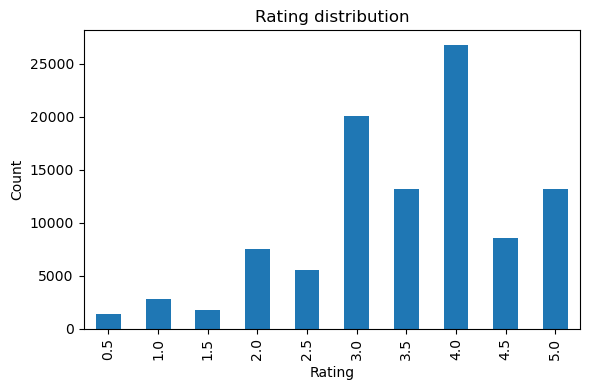


Top recommendations for user 210:


,movieId,title,predicted_score
0,706,Sunset Park (1996),5.0
1,779,'Til There Was You (1997),5.0
2,889,1-900 (06) (1994),5.0
3,2573,Tango (1998),5.0
4,2665,Earth vs. the Flying Saucers (1956),5.0


In [8]:
#Part D: Orchestration – one function to run everything
def run_pipeline(user_id_for_demo=1):
    # A: ingest
    ratings, movies = ingest_data(RATINGS_PATH, MOVIES_PATH)
    print("Loaded:", ratings.shape, "ratings |", movies.shape, "movies")
    
    # B: process
    data, user_item = process_data(ratings, movies)
    print("User–item matrix shape:", user_item.shape)
    
    # C1: CF model
    item_sim_df = build_item_sim_matrix(user_item)
    
    # C2: HF integration
    hf_df = hf_analyse_titles(movies, n=5)
    print("\nHugging Face sample on titles:")
    display(hf_df)
    
    # E: visualisation
    visualize_data(ratings)
    
    # Simple recommendation demo
    print(f"\nTop recommendations for user {user_id_for_demo}:")
    recs = recommend_top_n(user_item, item_sim_df, movies, user_id=user_id_for_demo, n=5, k=10)
    display(recs)
    
    return {
        "ratings": ratings,
        "movies": movies,
        "user_item": user_item,
        "item_sim_df": item_sim_df,
        "hf_df": hf_df,
        "recs": recs
}

# Actually run the whole pipeline once
results = run_pipeline(user_id_for_demo=210)
